During data cleaning it became clear that a significant subset of application table is dedicated for defining the neighbourhood of the house. The data also seemed to be susceptible to collinearity and the need for dimensionality reduction and unsupervised learning was recognized, consequently this notebook will:
* Perform EDA on the house parameter variables.
* Attempt dimensionality reduction and unsupervised learning techniques
* Evaluate effect of these on competition performance. 

In [3]:


import pandas as pd
import pickle as pkl
import importlib
import lightgbm

from helpers import table_navigator
from helpers import preprocessing
from helpers.utils import sklearn_helper
from helpers import submissions
from logging.config import valid_ident
import operator
import itertools
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from helpers.utils import plotting_helper



plotting_helper.set_plot_style()


# Preparation

In [4]:
app = preprocessing.load_pkl_to_preprocessor('application_train')
app.convert_all('category')
print(app.column_structure)

Loading tables: ['application_train.csv']
loaded application_train with shape (307511, 122)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
{'core_identification': ['SK_ID_CURR', 'TARGET'], 'loan_basics': ['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'], 'financial_info': ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'], 'assets': ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'OWN_CAR_AGE'], 'time_features': ['DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'HOUR_APPR_PROCESS_START'], 'contact_flags': ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'], 'demographics': ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH'], 'external_sources': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], 'location_features': ['REGION_POPULATION_RELATIVE', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION'

We then identify the housing data subset of interest.

In [78]:
housing_structure = {key:app.column_structure[key] for key in ['building_properties','building_avg', 'building_mode', 'building_medi']}

print("housing_structure:", housing_structure)
housing_columns = list(itertools.chain(*housing_structure.values()))
print("housing_columns:", housing_columns)

housing_structure: {'building_properties': ['EMERGENCYSTATE_MODE', 'FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE'], 'building_avg': ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'], 'building_mode': ['APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'TOTALAREA_MODE'], 'building_medi': ['APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI'

This data is prepared for simple use.

In [79]:
house_df = app.data[housing_columns+ ['TARGET']]
display(house_df)

,EMERGENCYSTATE_MODE,FONDKAPREMONT_MODE,WALLSMATERIAL_MODE,HOUSETYPE_MODE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TARGET
0,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,True
1,No,reg oper account,Block,block of flats,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,False
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,No,reg oper account,"Stone, brick",block of flats,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,...,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,False
307507,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,...,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,False
307508,No,reg oper account,Panel,block of flats,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,...,0.00,0.2069,0.1667,0.2083,NaN,0.0855,0.9445,0.0000,0.0000,False
307509,No,NaN,"Stone, brick",block of flats,0.0124,NaN,0.9771,NaN,NaN,NaN,...,NaN,0.0690,0.0417,NaN,NaN,NaN,0.0062,NaN,NaN,True


# PCA of current features

<Figure size 800x600 with 0 Axes>

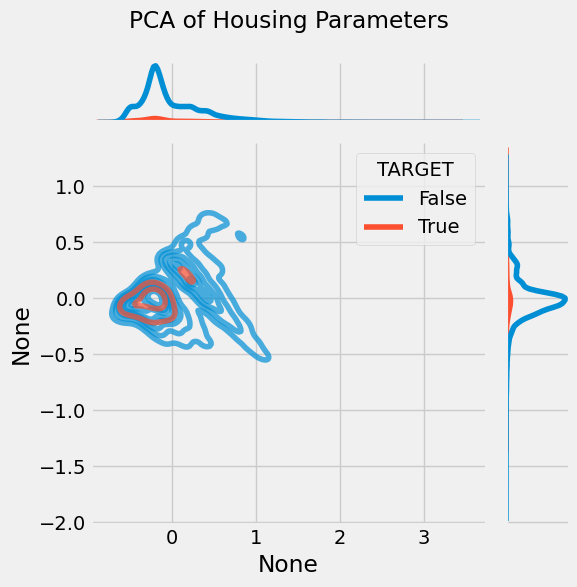

In [ ]:
X = house_df.drop('TARGET').select_dtypes(include=['number']).dropna()

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.jointplot(
    x=principal_components[:, 0], 
    y=principal_components[:, 1], 
    hue=house_df['TARGET'], 
    fill=False, 
    alpha=0.7, 
    kind='kde', 
    thresh=0., 
    cut=0
)

plt.suptitle('PCA of Housing Parameters')
plt.tight_layout()


two first PCA components are unable to capture any meaningful patterns of target distribution.

# EDA

## Correlation and collinearity

Text(0.5, 1.0, 'Pearson correlation for house neighbourhood parameters')

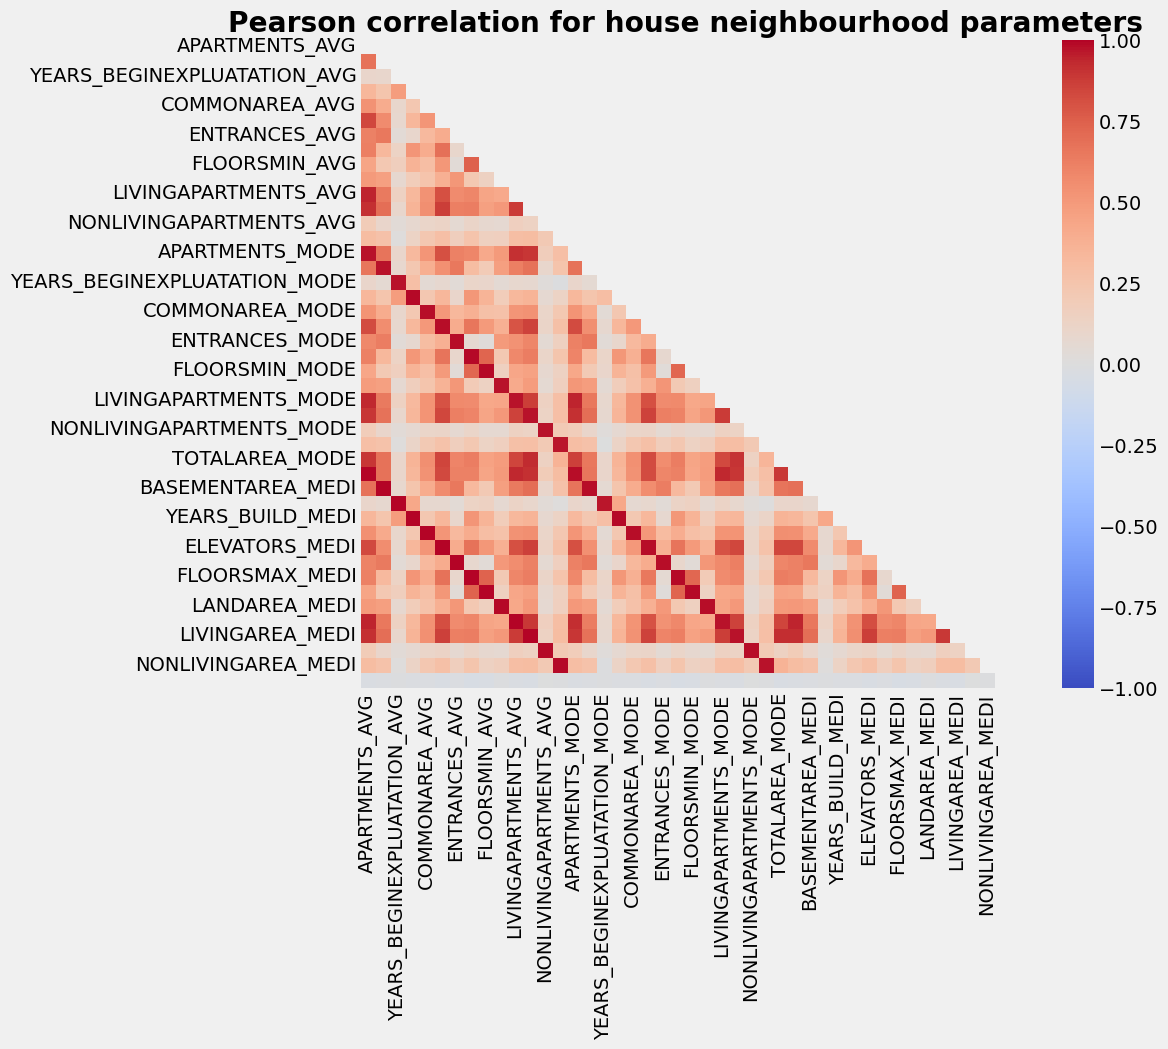

In [46]:
from helpers.utils import plotting_helper
importlib.reload(plotting_helper)
plotting_helper.corr_triangle(house_df, 'pearson', "TARGET", False);
plt.title("Pearson correlation for house neighbourhood parameters")

* There is significant covariance between numerous features.
* Average (mean), Median, Mode twin statistics are very strongly correlated, which would cause linear models to fail.
    * The broad trends (ignoring hard values) seem to be mostly repeated.
* There is no association between these and the target variable.
* The broad trends, when 

Our choice of tree ensemble model is more resistant to multicollinearity than linear methods, which should decrease impact of this issue.


## Comparison of building avg, median, and mode distributions.

In [77]:
display(house_df)

,EMERGENCYSTATE_MODE,FONDKAPREMONT_MODE,WALLSMATERIAL_MODE,HOUSETYPE_MODE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TARGET
0,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,True
1,No,reg oper account,Block,block of flats,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,False
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,No,reg oper account,"Stone, brick",block of flats,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,...,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,False
307507,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,...,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,False
307508,No,reg oper account,Panel,block of flats,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,...,0.00,0.2069,0.1667,0.2083,NaN,0.0855,0.9445,0.0000,0.0000,False
307509,No,NaN,"Stone, brick",block of flats,0.0124,NaN,0.9771,NaN,NaN,NaN,...,NaN,0.0690,0.0417,NaN,NaN,NaN,0.0062,NaN,NaN,True


### Correlation

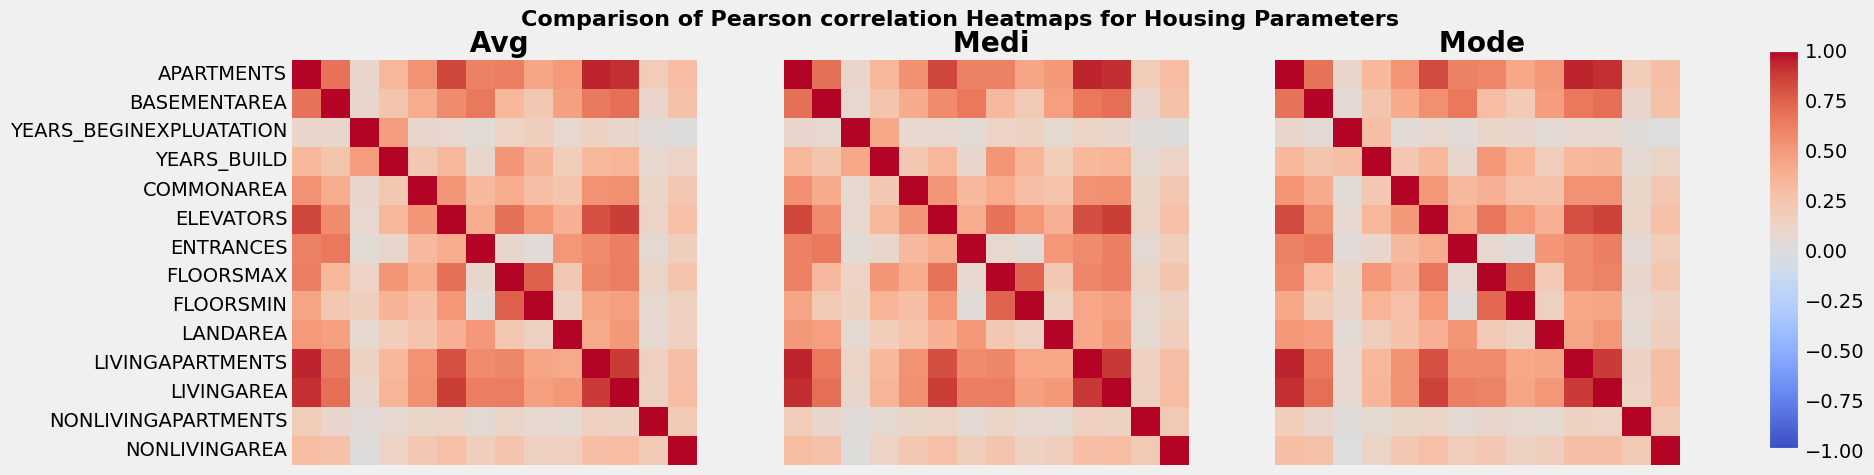

In [149]:
def plot_corr_table(df, suffix, ax) -> None:
    df = df.copy()
    df = df.select_dtypes(include=['number'])
    columns = [col for col in df.columns if suffix in col]
    
    df = df[columns]
    df.columns = [col.replace(suffix, '') for col in df.columns]
    
    corr = df.corr()
    sns.heatmap(corr, ax=ax, cmap='coolwarm', annot=False, fmt=".2f", square=True, center =0, vmax=1, vmin=-1)

    #ax.set_yticklabels([])
    ax.set_xticklabels([])


metric_suffixes = ['_AVG', '_MEDI', '_MODE']
titles = ['Average (Mean)', 'Median', 'Mode']

def plot_metric_comparison(df, metric_suffixes, sup_title, titles=None) -> None:
    fig, axes = plt.subplots(1, len(metric_suffixes), figsize=(16, 5))
    
    for ax, suffix in zip(axes, metric_suffixes):
        plot_corr_table(df, suffix, ax)
        ax.set_title(suffix.replace('_', ' ').title())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    plt.suptitle(sup_title, fontsize=16, fontweight='bold')


    for ax in axes:
        ax.collections[0].colorbar.remove()

    for ax in axes[1:] :
        ax.set_yticklabels([])
        

    def add_colorbar(fig)-> None:
        cbar_ax = fig.add_axes([1.005, 0.1, 0.02, 0.8])  # Position: [left, bottom, width, height]
        sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax)

    add_colorbar(fig)

plot_metric_comparison(house_df.drop(columns = 'TOTALAREA_MODE'), metric_suffixes, 'Comparison of Pearson correlation Heatmaps for Housing Parameters', titles)

In [153]:
house_df

,EMERGENCYSTATE_MODE,FONDKAPREMONT_MODE,WALLSMATERIAL_MODE,HOUSETYPE_MODE,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TARGET
0,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,True
1,No,reg oper account,Block,block of flats,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,False
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,No,reg oper account,"Stone, brick",block of flats,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,...,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,False
307507,No,reg oper account,"Stone, brick",block of flats,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,...,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,False
307508,No,reg oper account,Panel,block of flats,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,...,0.00,0.2069,0.1667,0.2083,NaN,0.0855,0.9445,0.0000,0.0000,False
307509,No,NaN,"Stone, brick",block of flats,0.0124,NaN,0.9771,NaN,NaN,NaN,...,NaN,0.0690,0.0417,NaN,NaN,NaN,0.0062,NaN,NaN,True


        APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  \
0               0.0247            0.0369                       0.9722   
1               0.0959            0.0529                       0.9851   
2                  NaN               NaN                          NaN   
3                  NaN               NaN                          NaN   
4                  NaN               NaN                          NaN   
...                ...               ...                          ...   
307506          0.2021            0.0887                       0.9876   
307507          0.0247            0.0435                       0.9727   
307508          0.1031            0.0862                       0.9816   
307509          0.0124               NaN                       0.9771   
307510          0.0742            0.0526                       0.9881   

        YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  \
0                0.6192          0.0143           

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high yli

        APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  \
0               0.0247            0.0369                       0.9722   
1               0.0959            0.0529                       0.9851   
2                  NaN               NaN                          NaN   
3                  NaN               NaN                          NaN   
4                  NaN               NaN                          NaN   
...                ...               ...                          ...   
307506          0.2021            0.0887                       0.9876   
307507          0.0247            0.0435                       0.9727   
307508          0.1031            0.0862                       0.9816   
307509          0.0124               NaN                       0.9771   
307510          0.0742            0.0526                       0.9881   

        YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  \
0                0.6192          0.0143           

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


{'_avg': Empty DataFrame
 Columns: []
 Index: [],
 '_mode': Empty DataFrame
 Columns: []
 Index: [],
 '_medi': Empty DataFrame
 Columns: []
 Index: []}

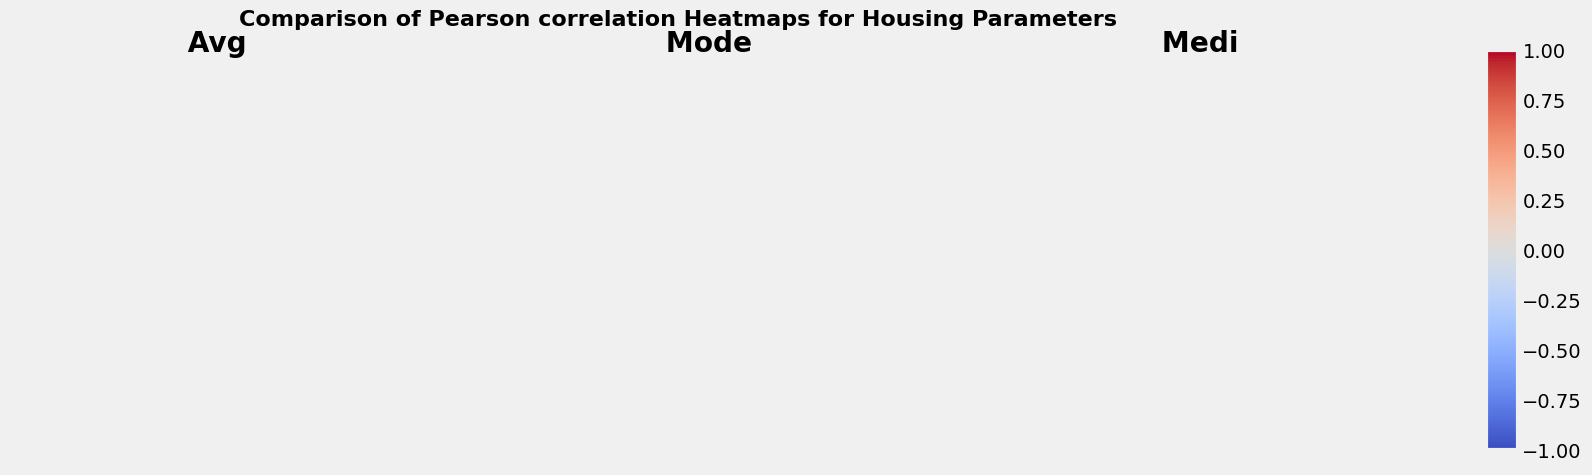

In [ ]:
from helpers import one_off_plots
importlib.reload(one_off_plots)

metric_suffixes = ['_AVG', '_MEDI', '_MODE']
titles = ['Average (Mean)', 'Median', 'Mode']

one_off_plots.plot_metric_comparison(house_df.drop(columns = 'TOTALAREA_MODE'), metric_suffixes, 'Comparison of Pearson correlation Heatmaps for Housing Parameters', titles)

* Feature correlation distributions are near identical.
* These values should be highly interchangeable for 

# Average correlation

### median features correlation

Even pearson correlations 

We firs